In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_olivetti_faces

NOTA RELEVANTE:

La gran mayoria del codigo fue sacado del material que el profesor nos brindo en clases

In [2]:
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X_faces = faces.data        # (400, 4096)
y_faces = faces.target      # 0..39 (identidad de la persona)

print(f"Shape: {X_faces.shape}  |  Personas: {len(np.unique(y_faces))}  |  Imágenes por persona: 10")
print(f"Rango de valores: [{X_faces.min():.2f}, {X_faces.max():.2f}]")

Shape: (400, 4096)  |  Personas: 40  |  Imágenes por persona: 10
Rango de valores: [0.00, 1.00]


In [3]:
# Centrar: restar la cara promedio
mean_face = X_faces.mean(axis=0)
X_faces_c = X_faces - mean_face

# SVD completa (400 muestras x 4096 features — manejable con full_matrices=False)
U, s, Vt = np.linalg.svd(X_faces_c, full_matrices=False)
# U: (400, 400), s: (400,), Vt: (400, 4096)

var_exp_faces = (s**2) / (s**2).sum()
k90 = np.searchsorted(np.cumsum(var_exp_faces), 0.90) + 1
k95 = np.searchsorted(np.cumsum(var_exp_faces), 0.95) + 1
print(f"PC1: {var_exp_faces[0]:.1%}  |  PC2: {var_exp_faces[1]:.1%}  |  Top-10: {var_exp_faces[:10].sum():.1%}")
print(f"Componentes para 90% de varianza: {k90}  |  para 95%: {k95}  (de 4096 features originales)")

PC1: 23.8%  |  PC2: 14.0%  |  Top-10: 65.6%
Componentes para 90% de varianza: 66  |  para 95%: 123  (de 4096 features originales)


Parte A

In [4]:
k99 = np.searchsorted(np.cumsum(var_exp_faces), 0.99) + 1

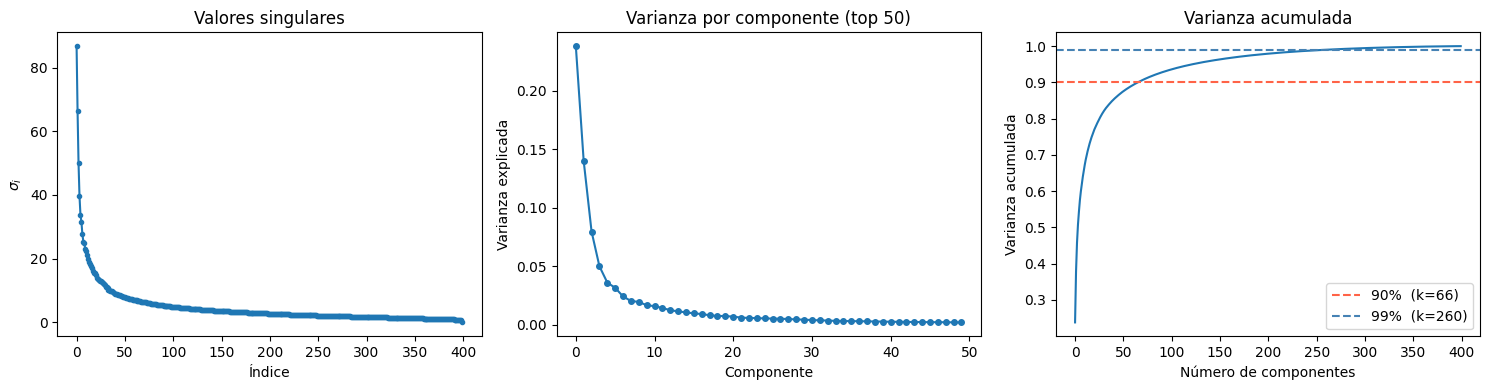

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# valores singulares crudos
axes[0].plot(s, 'o-', ms=3)
axes[0].set_xlabel('Índice')
axes[0].set_ylabel('$\\sigma_i$')
axes[0].set_title('Valores singulares')


axes[1].plot(var_exp_faces[:50], 'o-', ms=4)
axes[1].set_xlabel('Componente')
axes[1].set_ylabel('Varianza explicada')
axes[1].set_title('Varianza por componente (top 50)')


axes[2].plot(np.cumsum(var_exp_faces), '-')
axes[2].axhline(0.90, color='tomato',    ls='--', label=f'90%  (k={k90})')
axes[2].axhline(0.99, color='steelblue', ls='--', label=f'99%  (k={k99})')
axes[2].set_xlabel('Número de componentes')
axes[2].set_ylabel('Varianza acumulada')
axes[2].set_title('Varianza acumulada')
axes[2].legend()

plt.tight_layout()
plt.show()

Los valores singulares caen bruscamente en los primeros componentes y se aplanan rápidamente. Con solo k = 66 componentes se captura el 90% de la varianza, y con k = 260 el 99%, sobre un total de 4096 features. Esto confirma que la información relevante de las caras está concentrada en muy pocas direcciones del espacio de píxeles.La caída pronunciada al inicio tiene sentido dado que todas las imágenes son 
rostros frontales parecidos entre sí, por lo que unas pocas eigenfaces bastan 
para capturar las diferencias más importantes entre fotos

Parte B

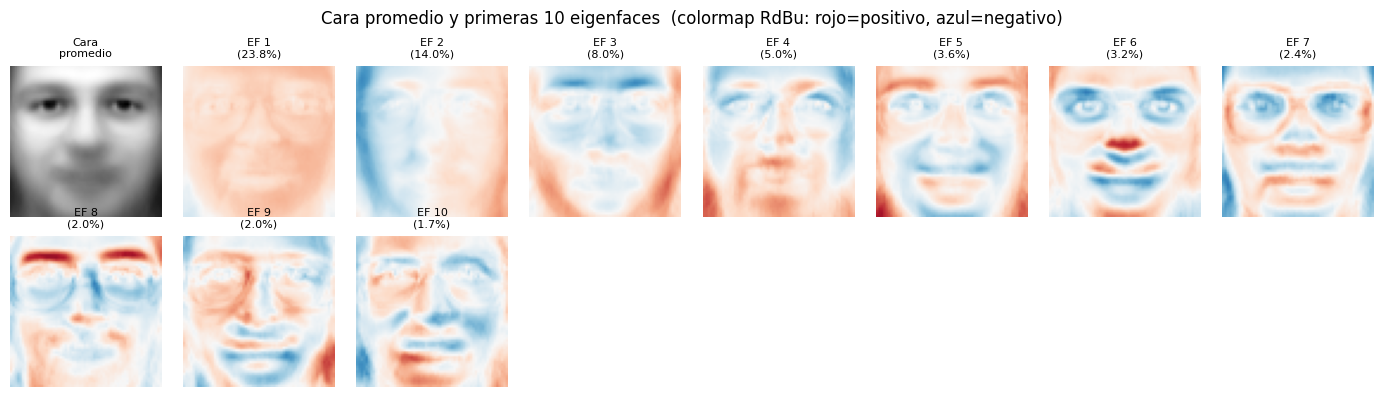

In [ ]:
# Cara promedio + primeras 10 eigenfaces
n_eigen = 10
fig, axes = plt.subplots(2, 8, figsize=(14, 4))


axes[0, 0].imshow(mean_face.reshape(64, 64), cmap='gray')
axes[0, 0].set_title("Cara\npromedio", fontsize=8)
axes[0, 0].axis('off')


for i, ax in enumerate(axes.flat[1:n_eigen + 1]):
    eigenface = Vt[i].reshape(64, 64)
    ax.imshow(eigenface, cmap='RdBu_r', vmin=-0.07, vmax=0.07)
    ax.set_title(f"EF {i+1}\n({var_exp_faces[i]:.1%})", fontsize=8)
    ax.axis('off')

for ax in axes.flat[n_eigen + 1:]:
    ax.axis('off')

fig.suptitle("Cara promedio y primeras 10 eigenfaces  (colormap RdBu: rojo=positivo, azul=negativo)")
plt.tight_layout()
plt.show()

La imagen promedio es una cara frontal genérica, resultado de promediar las 400 fotos del dataset.

**v1(23.8%)** el modo de mayor varianza captura diferencias de brillo global  
toda la cara en rojo indica que lo que más varía entre fotos es cuán iluminada está la cara en general.Es el componente dominante porque la iluminación es la fuente de variación más grande entre imágenes del dataset.

**v2 (14.0%):** captura iluminación lateral — un lado rojo y el otro azul, 
correspondiente a fotos tomadas con luz desde distintos ángulos.Tiene sentido  que sea el segundo componente más importante ya que la dirección de la luz es otra fuente de variación sistemática

**v3 (8.0%):** captura una división vertical del rostro — frente y ojos en azul, 
boca y mentón en rojo, asociado a diferencias de expresión o inclinación de la cabeza.A partir del tercer componente los patrones se vuelven más específicos y su varianza explicada cae progresivamente

Parte C

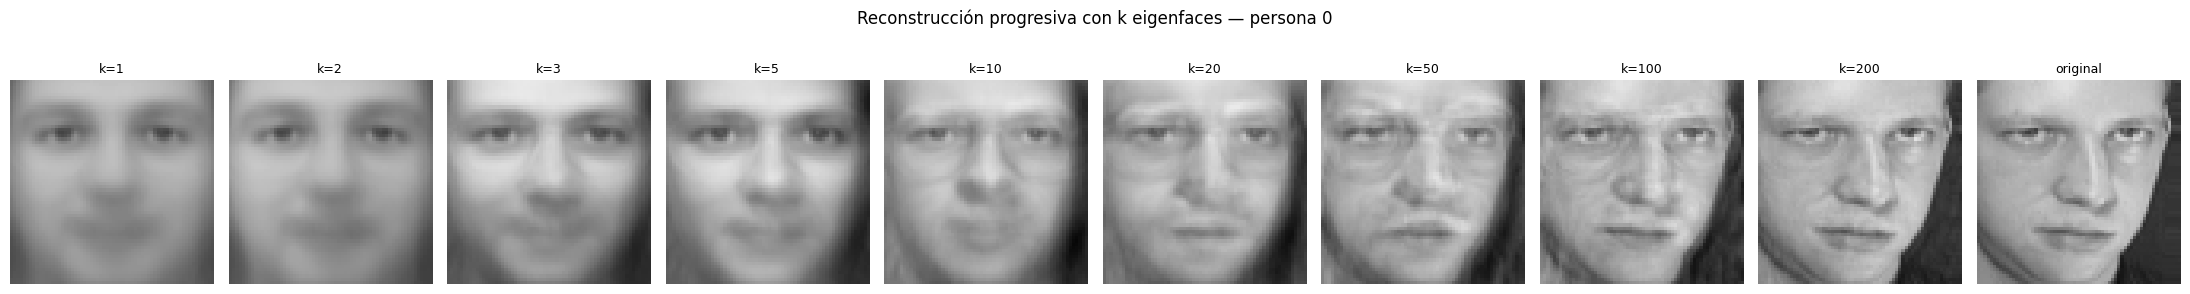

In [7]:
k_values_faces = [1, 2, 3, 5, 10, 20, 50, 100, 200]

Z_full_faces = U * s

# Una sola imagen (persona 0)
img_idx  = np.where(y_faces == 0)[0][0]
x_orig   = X_faces[img_idx]
z_coords = Z_full_faces[img_idx]

n_cols_f = len(k_values_faces) + 1
fig, axes = plt.subplots(1, n_cols_f, figsize=(2.2 * n_cols_f, 3))

for col, k in enumerate(k_values_faces):
    recon = z_coords[:k] @ Vt[:k] + mean_face
    recon = np.clip(recon, 0, 1)
    axes[col].imshow(recon.reshape(64, 64), cmap='gray', vmin=0, vmax=1)
    axes[col].set_title(f"k={k}", fontsize=9)
    axes[col].axis('off')

axes[-1].imshow(x_orig.reshape(64, 64), cmap='gray', vmin=0, vmax=1)
axes[-1].set_title("original", fontsize=9)
axes[-1].axis('off')

fig.suptitle("Reconstrucción progresiva con k eigenfaces — persona 0", y=1.02)
plt.tight_layout()
plt.show()

Con k=1 a k=3 la reconstrucción es borrosa y sin identidad — solo se recupera 
la forma general del rostro e iluminación básica.

Con k=10 a k=20 la reconstrucción es visualmente satisfactoria: se reconoce 
a la persona y aparecen rasgos faciales distinguibles. Esto es consistente con 
que ese rango corresponde aproximadamente al 65% de varianza explicada, 
suficiente para preservar la identidad visual

A partir de k=50 la imagen es casi idéntica al original, y las mejoras 
posteriores (k=100, k=200) son apenas perceptibles